In [1]:
import json
import sys
import matplotlib.pyplot as plt
from pathlib import Path

import numpy as np
import pandas as pd

from motion_estimator import MotionEstimator

In [2]:
config_file = Path('test_config_altitude.json')
csv = Path('raw_data_output_altitude.csv')

# config_file = Path('test_config_azimuth.json')
# csv = Path('raw_data_output_azimuth.csv')
use_edn = True
fs = 104

In [3]:
def load_config(config_path: Path | None) -> dict:
    default = Path("test_config_altitude.json")
    if config_path and config_path.exists():
    	with open(config_path, "r") as f:
    		return json.load(f)
    if default.exists():
    	with open(default, "r") as f:
    		return json.load(f)
    return {"test_sequence": []}


def load_dataframe(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    required = ["timestamp", "accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z"]
    missing = [c for c in required if c not in df.columns]
    if missing:
    	raise ValueError(f"Missing columns in {csv_path}: {missing}")
    for c in required[1:]:
    	df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=required)
    return df


def edn_to_ned(df: pd.DataFrame) -> pd.DataFrame:
    # Copy to avoid modifying caller
    df = df.copy()
    # Accelerometer
    df["accel_x"], df["accel_y"], df["accel_z"] = (
    	df["accel_z"],
    	df["accel_x"],
    	-df["accel_y"],
    )
    # Gyroscope
    df["gyro_x"], df["gyro_y"], df["gyro_z"] = (
    	df["gyro_z"],
    	df["gyro_x"],
    	-df["gyro_y"],
    )
    return df


def regularize_timestamps(ts: np.ndarray, fs: float) -> np.ndarray:
    current = float(ts[0])
    updated: list[float] = []
    for i in range(1, len(ts)):
    	if ts[i] + 10 < ts[i - 1]:
    		current = float(ts[i])
    	updated.append(current)
    	current += 1.0 / fs
    updated.append(current)
    return np.array(updated, dtype=float)


def segment_by_gaps(df: pd.DataFrame, gap_s: float = 5.0) -> list[tuple[int, int]]:
    ts = df["timestamp"].to_numpy()
    gaps = np.where(np.abs(np.diff(ts)) > gap_s)[0]
    bounds: list[tuple[int, int]] = []
    start = 0
    for gi in gaps:
    	bounds.append((start, gi + 1))
    	start = gi + 1
    bounds.append((start, len(df)))
    return bounds


def map_segments_to_config(df: pd.DataFrame, config: dict) -> list[dict]:
    bounds = segment_by_gaps(df)
    seq = config.get("test_sequence", [])
    segments: list[dict] = []
    for i, (s, e) in enumerate(bounds):
    	meta = seq[i] if i < len(seq) else {"test_id": i}
    	segments.append({
    		"test_id": int(meta.get("test_id", i)),
    		"data": df.iloc[s:e].reset_index(drop=True),
    		"config": meta,
    		"start_idx": s,
    		"end_idx": e,
    	})
    return segments

def process_segment_with_estimator(segment_data: pd.DataFrame, estimator: MotionEstimator) -> pd.DataFrame:
    """Process a segment through the MotionEstimator"""
    results = []
    
    for i, row in segment_data.iterrows():
        # Convert from mg to g for consistency with MotionEstimator
        accel_raw = [row["accel_x"], row["accel_y"], row["accel_z"]]  # Already in mg
        gyro_raw = [row["gyro_x"], row["gyro_y"], row["gyro_z"]]      # Already in dps
        
        output = estimator.update(accel_raw, gyro_raw, row["timestamp"])
        output["sample_idx"] = i
        results.append(output)
    
    return pd.DataFrame(results)

def detect_angle_changes(segment_df: pd.DataFrame, config: dict, fs: float = 104.0) -> dict:
    """Detect angle changes in processed segment data"""
    change_time = config['change_time'] * 104
    n_samples = len(segment_df)
    time_passed = int(change_time * 0.1)
    
    # Calculate mean angles in stable regions
    start_angles = segment_df.iloc[change_time-time_passed: change_time+time_passed][["pitch_deg", "yaw_deg", "roll_deg"]].abs().max()
    # end_angles = segment_df.iloc[change_time+2*time_passed:stable_end][["pitch_deg", "yaw_deg", "roll_deg"]].mean()
    
    print(segment_df.head())
    # Calculate changes
    detected_changes = {
    	"theta_change": start_angles["pitch_deg"],
    	"phi_change": start_angles["yaw_deg"],
    	"psi_change": start_angles["roll_deg"]
    }

    return detected_changes
def analyze_segment_errors(segment: dict, estimator: MotionEstimator, fs: float = 104) -> dict:
    """Analyze errors for a single segment"""
    test_config = segment["config"]

    processed_df = process_segment_with_estimator(segment["data"], estimator)
    detected = detect_angle_changes(processed_df, test_config, fs)
    detected['max_dps'] = segment["data"][["gyro_x", "gyro_y", "gyro_z"]].max().max()

    detection_threshold = 2.0  # degrees
    result = {
        "test_id": segment["test_id"],
        "description": test_config.get("description", ""),
        "max_dps": detected["max_dps"],
        "expected_detectable": test_config.get("expected_detectable", True),
        "processed_data": processed_df
    }

    if test_config.get("power_state", "off") != "on":
        return None

    # θ (altitude)
    if "theta_change" in test_config:
        expected_theta = test_config["theta_change"]
        theta_error = abs(detected["theta_change"] - expected_theta)
        theta_detected = theta_error < detection_threshold if expected_theta != 0 else theta_error < 0.5
        result.update({
            "expected_theta": expected_theta,
            "detected_theta": detected["theta_change"],
            "theta_error": theta_error,
            "theta_detected": theta_detected,
        })

    # φ (azimuth)
    if "phi_change" in test_config:
        expected_phi = test_config["phi_change"]
        phi_error = abs(detected["phi_change"] - expected_phi)
        phi_detected = phi_error < detection_threshold if expected_phi != 0 else phi_error < 0.5
        result.update({
            "expected_phi": expected_phi,
            "detected_phi": detected["phi_change"],
            "phi_error": phi_error,
            "phi_detected": phi_detected,
        })
    return result


In [4]:
config = load_config(config_file)
config

{'sensor_specs': {'accel_range': 2,
  'gyro_range': 2000,
  'odr': 104,
  'noise_floor': 0.000577},
 'initial_conditions': {'imu_offset': 0.3,
  'theta_start': 0.3,
  'phi_start': 0.0,
  'psi_start': 0.0},
 'test_sequence': [{'test_id': 0,
   'duration': 60,
   'change_time': 20,
   'description': 'Baseline - no movement',
   'power_state': 'on',
   'theta_change': 0,
   'expected_detectable': False},
  {'test_id': 1,
   'duration': 60,
   'change_time': 20,
   'description': '5Â° theta rotation (power off)',
   'power_state': 'off',
   'theta_change': 5,
   'expected_detectable': True},
  {'test_id': 2,
   'duration': 60,
   'change_time': 20,
   'description': '4.7Â° theta rotation (power on)',
   'power_state': 'on',
   'theta_change': 4.7,
   'expected_detectable': True},
  {'test_id': 3,
   'duration': 30,
   'change_time': 15,
   'description': '10.2Â° theta rotation (power on)',
   'power_state': 'on',
   'theta_change': 10.2,
   'expected_detectable': True},
  {'test_id': 4,
  

In [5]:
df = load_dataframe(csv)
df.head()

,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z
0,0.743,-18,990,58,5670,-4270.0,-490.0
1,0.743,-18,991,56,140,-490.0,-140.0
2,0.743,-16,989,58,420,-490.0,-210.0
3,0.743,-17,988,58,420,-490.0,-140.0
4,0.743,-17,991,59,350,-490.0,-140.0


In [6]:
if use_edn:
    df = edn_to_ned(df)

df.head() 

,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z
0,0.743,58,-18,-990,-490.0,5670,4270.0
1,0.743,56,-18,-991,-140.0,140,490.0
2,0.743,58,-16,-989,-210.0,420,490.0
3,0.743,58,-17,-988,-140.0,420,490.0
4,0.743,59,-17,-991,-140.0,350,490.0


In [7]:
df["timestamp"] = regularize_timestamps(df["timestamp"].to_numpy(), fs)
df.head()

,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z
0,0.743000,58,-18,-990,-490.0,5670,4270.0
1,0.752615,56,-18,-991,-140.0,140,490.0
2,0.762231,58,-16,-989,-210.0,420,490.0
3,0.771846,58,-17,-988,-140.0,420,490.0
4,0.781462,59,-17,-991,-140.0,350,490.0


In [8]:
segments = map_segments_to_config(df, config)
print(f"Loaded {len(df)} samples, {len(segments)} segments from {csv}")
print(segments[0].keys())
segments[0]

Loaded 55615 samples, 12 segments from raw_data_output_altitude.csv
dict_keys(['test_id', 'data', 'config', 'start_idx', 'end_idx'])


{'test_id': 0,
 'data':       timestamp  accel_x  accel_y  accel_z  gyro_x  gyro_y  gyro_z
 0      0.743000       58      -18     -990  -490.0    5670  4270.0
 1      0.752615       56      -18     -991  -140.0     140   490.0
 2      0.762231       58      -16     -989  -210.0     420   490.0
 3      0.771846       58      -17     -988  -140.0     420   490.0
 4      0.781462       59      -17     -991  -140.0     350   490.0
 ...         ...      ...      ...      ...     ...     ...     ...
 7063  68.656462       60      -18     -991  -140.0     280   490.0
 7064  68.666077       61      -18     -989  -210.0     210   420.0
 7065  68.675692       61      -17     -991  -210.0     210   420.0
 7066  68.685308       61      -17     -991  -210.0     280   350.0
 7067  68.694923       58      -18     -991  -210.0     350   490.0
 
 [7068 rows x 7 columns],
 'config': {'test_id': 0,
  'duration': 60,
  'change_time': 20,
  'description': 'Baseline - no movement',
  'power_state': 'on',
  

In [9]:
estimator = MotionEstimator()


Processing segment 0: Baseline - no movement
    yaw_deg  pitch_deg   roll_deg  timestamp  sample_idx
0  0.007808  -0.067829  -3.472072   0.743000           0
1  0.013179  -0.137187  -6.874128   0.752615           1
2  0.016680  -0.207580 -10.208269   0.762231           2
3  0.018744  -0.278351 -13.475320   0.771846           3
4  0.019705  -0.349346 -16.676779   0.781462           4


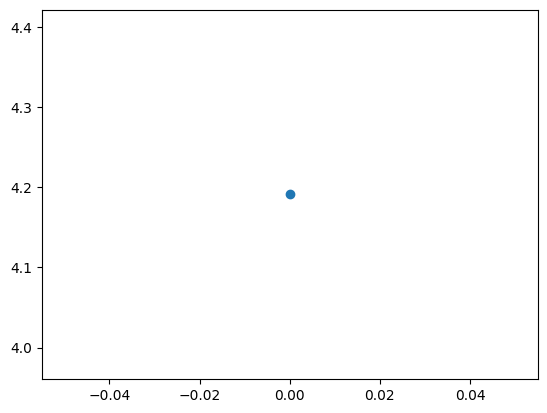


Processing segment 1: 5Â° theta rotation (power off)
     yaw_deg  pitch_deg    roll_deg  timestamp  sample_idx
0 -20.796834  -4.193606 -173.505175   0.743000           0
1 -20.546964  -4.278204 -173.615493   0.752615           1
2 -20.347256  -4.340687 -173.698389   0.762231           2
3 -20.194661  -4.398778 -173.759615   0.771846           3
4 -20.078093  -4.453312 -173.804114   0.781462           4

Processing segment 2: 4.7Â° theta rotation (power on)
     yaw_deg  pitch_deg    roll_deg  timestamp  sample_idx
0 -40.298058  -6.697932 -173.400662   0.743000           0
1 -40.047837  -6.759790 -173.512180   0.752615           1
2 -39.847860  -6.781594 -173.596826   0.762231           2
3 -39.695058  -6.785411 -173.660240   0.771846           3
4 -39.578331  -6.775824 -173.707249   0.781462           4


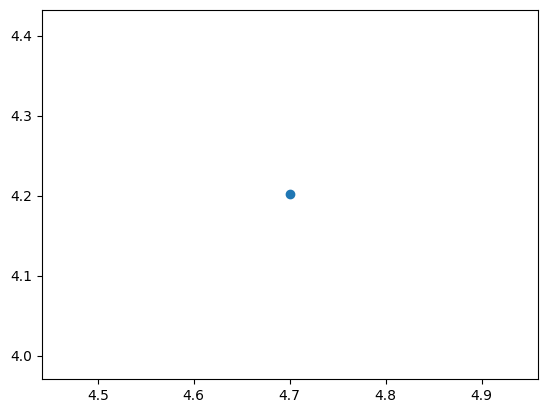


Processing segment 3: 10.2Â° theta rotation (power on)
     yaw_deg  pitch_deg    roll_deg  timestamp  sample_idx
0 -60.917768  -6.562645 -173.417797   0.743000           0
1 -60.667079  -6.625506 -173.529294   0.752615           1
2 -60.466586  -6.648841 -173.613844   0.762231           2
3 -60.313388  -6.654690 -173.676974   0.771846           3
4 -60.196201  -6.647344 -173.723971   0.781462           4


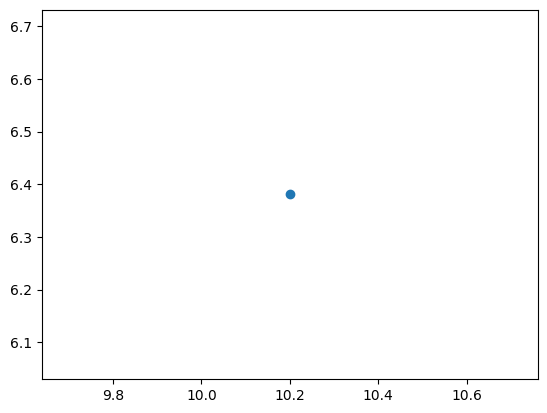


Processing segment 4: 10Â° theta return to 0 (power off)
     yaw_deg  pitch_deg    roll_deg  timestamp  sample_idx
0 -70.508599  -9.475799 -173.384477   0.743000           0
1 -70.258186  -9.524726 -173.496103   0.752615           1
2 -70.057904  -9.524073 -173.580788   0.762231           2
3 -69.904713  -9.498220 -173.644022   0.771846           3
4 -69.787686  -9.453695 -173.691088   0.781462           4

Processing segment 5: 15Â° theta rotation (power off)
     yaw_deg  pitch_deg    roll_deg  timestamp  sample_idx
0 -80.506933  -4.151913 -173.495396   0.743000           0
1 -80.256571  -4.261206 -173.605419   0.752615           1
2 -80.056330  -4.365840 -173.687247   0.762231           2
3 -79.903169  -4.478911 -173.746837   0.771846           3
4 -79.786322  -4.597847 -173.789396   0.781462           4

Processing segment 6: 15Â° theta return to 0 (power on)
     yaw_deg  pitch_deg    roll_deg  timestamp  sample_idx
0 -90.962681 -11.742697 -173.263296   0.743000           0
1 -9

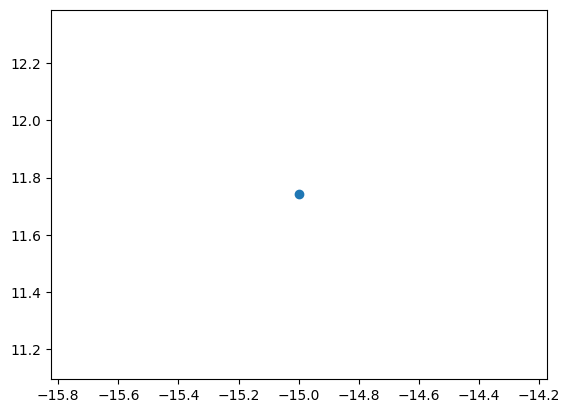


Processing segment 7: 5Â° theta rotation (power off)
      yaw_deg  pitch_deg    roll_deg  timestamp  sample_idx
0 -104.256494  -4.122496 -173.490782   0.743000           0
1 -104.006279  -4.209708 -173.601372   0.752615           1
2 -103.806462  -4.275498 -173.684371   0.762231           2
3 -103.653784  -4.335967 -173.745478   0.771846           3
4 -103.537151  -4.392002 -173.789804   0.781462           4

Processing segment 8: 5Â° theta return to 0 (power on)
      yaw_deg  pitch_deg    roll_deg  timestamp  sample_idx
0 -115.542218  -6.723276 -173.417372   0.743000           0
1 -115.291790  -6.797322 -173.528294   0.752615           1
2 -115.091654  -6.840322 -173.612014   0.762231           2
3 -114.938574  -6.871852 -173.674122   0.771846           3
4 -114.821790  -6.894602 -173.719524   0.781462           4


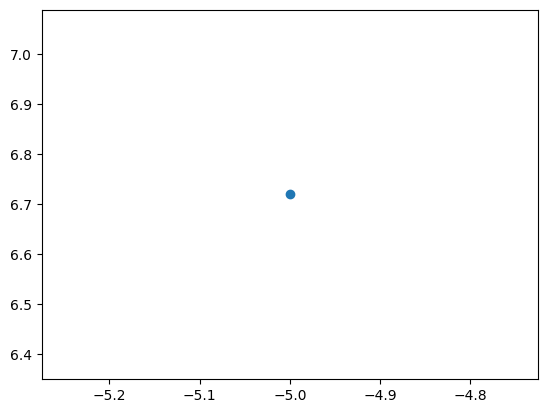


Processing segment 9: 4Â° theta rotation (offâ†’on)
      yaw_deg  pitch_deg    roll_deg  timestamp  sample_idx
0 -126.393743  -4.320729 -173.336784   0.743000           0
1 -126.143742  -4.403135 -173.447373   0.752615           1
2 -125.943934  -4.461239 -173.530865   0.762231           2
3 -125.791262  -4.513037 -173.592794   0.771846           3
4 -125.674635  -4.559868 -173.638073   0.781462           4

Processing segment 10: 3Â° theta rotation (offâ†’on)
      yaw_deg  pitch_deg    roll_deg  timestamp  sample_idx
0 -136.156637  -4.281984 -173.324840   0.743000           0
1 -135.906188  -4.362263 -173.435468   0.752615           1
2 -135.706036  -4.416135 -173.518958   0.762231           2
3 -135.552943  -4.462254 -173.580889   0.771846           3
4 -135.435993  -4.502488 -173.626301   0.781462           4

Processing segment 11: 1.2Â° theta rotation (offâ†’on)
      yaw_deg  pitch_deg    roll_deg  timestamp  sample_idx
0 -146.128827  -4.055364 -173.397260   0.743000          

In [10]:
processed_data_dict = {}
results = []

for segment in segments:
    print(f"\nProcessing segment {segment['test_id']}: {segment['config'].get('description', '')}")
    
    # Process segment
    result = analyze_segment_errors(segment, estimator)

    # Store processed data separately
    if result is not None:
        processed_data_dict[segment['test_id']] = result.pop('processed_data', None)
        results.append(result)
        if 'expected_theta' in result.keys():
            plt.scatter(result['expected_theta'], result['detected_theta'])
        if 'expected_phi' in result.keys():
            plt.scatter(result['expected_phi'], result['detected_phi'])
        plt.show()

results_df = pd.DataFrame(results)

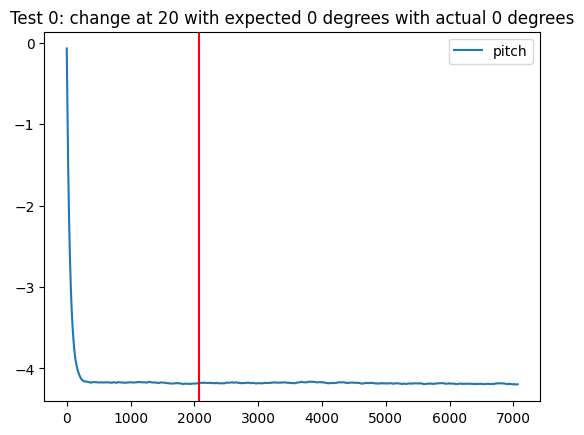

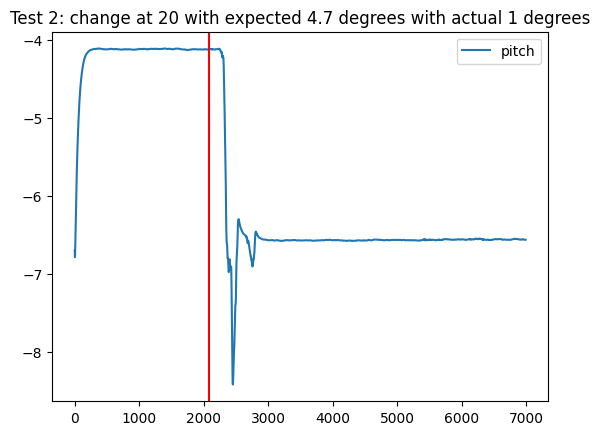

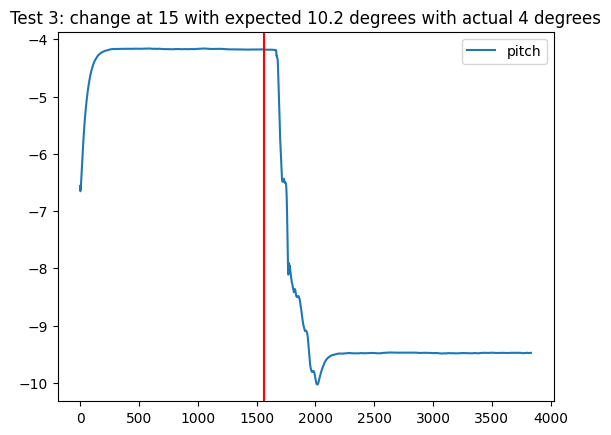

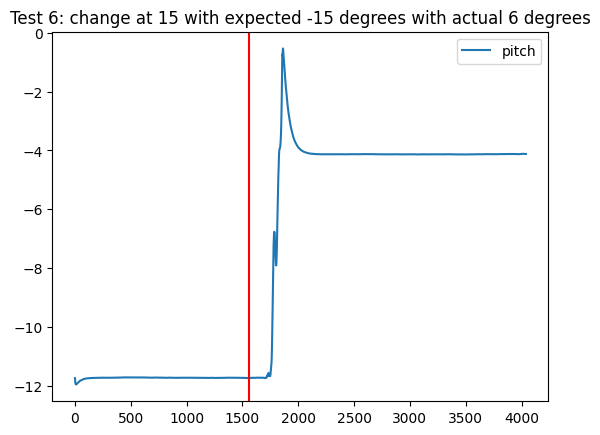

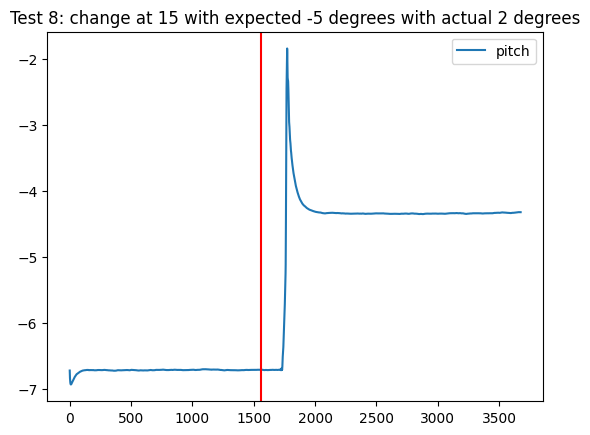

In [11]:
    for k,d in processed_data_dict.items():
        if 'phi_change' in segments[k]['config'].keys():
            change_time = segments[k]['config']['change_time']
            change = segments[k]['config']['phi_change'] if 'phi_change' in segments[k]['config'].keys() else segments[k]['config']['theta_change']

            delay = 10

            angle_before = d['yaw_deg'][(change_time - delay)*104:change_time*104].mean()
            angle_after = d['yaw_deg'][change_time*104:(change_time + delay)*104].mean()

            angle_delta = int(abs(angle_after-angle_before))
            plt.plot(d['yaw_deg'], label='yaw')
        if 'theta_change' in segments[k]['config'].keys():
            change_time = segments[k]['config']['change_time']
            change = segments[k]['config']['theta_change'] if 'theta_change' in segments[k]['config'].keys() else segments[k]['config']['theta_change']

            delay = 10

            angle_before = d['pitch_deg'][(change_time - delay)*104:change_time*104].mean()
            angle_after = d['pitch_deg'][change_time*104:(change_time + delay)*104].mean()

            angle_delta = int(abs(angle_after-angle_before))
            plt.plot(d['pitch_deg'], label='pitch')
        plt.axvline(change_time*104, color="r")
        plt.title(f"Test {k}: change at {change_time} with expected {change} degrees with actual {angle_delta} degrees")
        plt.legend()
        plt.show()